## Setup

In [343]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

In [3]:
# table from https://en.wikipedia.org/wiki/Guess_Who
table = pd.read_csv('simplified_table.csv', sep=';')

In [4]:
table

,Name,Gender,Eyes,Hair,Beard,Moustache,Big nose,Glasses,Hat
0,Alex,Male,Brown,Black,No,Yes,No,No,No
1,Alfred,Male,Blue,Light brown,No,Yes,No,No,No
2,Anita,Female,Blue,Blonde,No,No,No,No,No
3,Anne,Female,Brown,Black,No,No,Yes,No,No
4,Bernard,Male,Brown,Dark brown,No,No,Yes,No,Yes
5,Bill,Male,Brown,Light brown,Yes,No,No,No,No
6,Charles,Male,Brown,Blonde,No,Yes,No,No,No
7,Claire,Female,Brown,Light brown,No,No,No,Yes,Yes
8,David,Male,Brown,Blonde,Yes,No,No,No,Yes
9,Eric,Male,Brown,Blonde,No,No,No,No,Yes


# AI GUESSER

In [339]:
def random_person_row():
    random_person = random.choice(table['Name'].tolist())
    person_row = table[table['Name'] == random_person]
    return person_row

In [340]:
def inizialize_questions():
    global questions
    questions = []
    features = table.columns[1:]
    score = 0.0
    for feature in features:
        keys = table[feature].unique()
        for key in keys:
            questions.append({'feature': feature, 'key': key, 'score': score})

In [450]:
inizialize_questions()

In [451]:
questions

[{'feature': 'Gender', 'key': 'Male', 'score': 0.0},
 {'feature': 'Gender', 'key': 'Female', 'score': 0.0},
 {'feature': 'Eyes', 'key': 'Brown', 'score': 0.0},
 {'feature': 'Eyes', 'key': 'Blue', 'score': 0.0},
 {'feature': 'Hair', 'key': 'Black', 'score': 0.0},
 {'feature': 'Hair', 'key': 'Light brown', 'score': 0.0},
 {'feature': 'Hair', 'key': 'Blonde', 'score': 0.0},
 {'feature': 'Hair', 'key': 'Dark brown', 'score': 0.0},
 {'feature': 'Hair', 'key': 'White', 'score': 0.0},
 {'feature': 'Beard', 'key': 'No', 'score': 0.0},
 {'feature': 'Beard', 'key': 'Yes', 'score': 0.0},
 {'feature': 'Moustache', 'key': 'Yes', 'score': 0.0},
 {'feature': 'Moustache', 'key': 'No', 'score': 0.0},
 {'feature': 'Big nose', 'key': 'No', 'score': 0.0},
 {'feature': 'Big nose', 'key': 'Yes', 'score': 0.0},
 {'feature': 'Glasses', 'key': 'No', 'score': 0.0},
 {'feature': 'Glasses', 'key': 'Yes', 'score': 0.0},
 {'feature': 'Hat', 'key': 'No', 'score': 0.0},
 {'feature': 'Hat', 'key': 'Yes', 'score': 0.0}

##### Using sigmoid function

In [405]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))

Text(0.5, 1.0, 'Sigmoid Function')

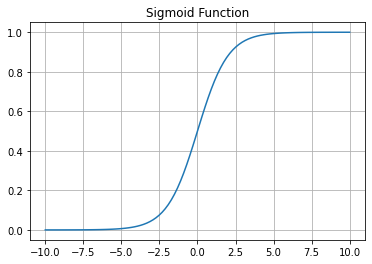

In [406]:
# plot sigmoid function
x = np.linspace(-10, 10, 100)
y = sigmoid(x)
plt.plot(x, y)
plt.grid(True)
plt.title("Sigmoid Function")

In [452]:
def evaluate_total_score(questions):
    return sum([sigmoid(q['score']) for q in questions])

In [453]:
def random_question(questions):
    total_score = evaluate_total_score(questions)
    random_number = random.random() * total_score
    cumulative_score = 0.0
    for idx, question in enumerate(questions):
        cumulative_score += sigmoid(question['score'])
        if cumulative_score >= random_number:
            return (idx, question)
    return (len(questions) - 1, questions[-1])

In [454]:
def plot_distribution_of_questions(questions, trials=10_000):
    rq_list = []
    for _ in range(trials):
        rq_list.append(random_question(questions)[1])
    sns.histplot([rq['feature'] + ": " + str(rq['key']) for rq in rq_list], discrete=True)
    plt.xticks(rotation=90)

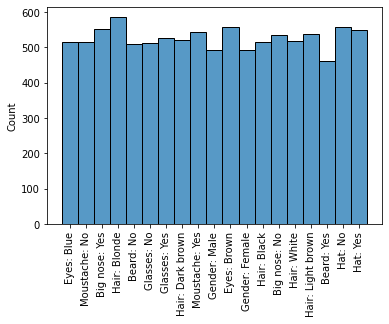

In [455]:
plot_distribution_of_questions(questions)

In [ ]:
def train(print_logs=False, on_first_n_questions_only=0):
    global questions_to_update, baseline, baseline_beta
    person_row = random_person_row()
    curr_table = table.copy()
    num_questions = 1
    available_questions = questions.copy()
    alpha = 0.05
    gamma = 0.9
    episode_log = []
    while len(curr_table) > 2 and len(available_questions) > 0:
        rq_idx, rq = random_question(available_questions)
        available_questions.pop(rq_idx)
        feature = rq['feature']
        key = rq['key']
        answer = 'Yes' if person_row[feature].values[0] == key else 'No'
        filtered_table = (
            curr_table[curr_table[feature] == key]
            if answer == 'Yes'
            else curr_table[curr_table[feature] != key]
        )
        if len(filtered_table) == len(curr_table):
            if print_logs:
                print(f"Asked about {feature} == {key}, answer: {answer}, but no filtering applied as it would eliminate no options.")
            continue
        size_variation = len(filtered_table) / len(curr_table)
        reward = 2/3 - size_variation
        episode_log.append((rq_idx, reward, num_questions))
        if print_logs:
            print(f"Asked about {feature} == {key}, answer: {answer}, table size: {len(curr_table)} -> {len(filtered_table)}")
        curr_table = filtered_table
        if on_first_n_questions_only != 0 and num_questions >= on_first_n_questions_only:
            break
        num_questions += 1
    if not episode_log:
        return
    episode_return = sum(reward for _, reward, _ in episode_log) / len(episode_log)
    baseline = (1 - baseline_beta) * baseline + baseline_beta * episode_return
    for rq_idx, reward, t in episode_log:
        advantage = reward - baseline
        score_variation = alpha * advantage * (gamma ** (t-1))
        questions_to_update[rq_idx]['score'] += score_variation

ATTEMPTS=10_000
After 0 attempts:


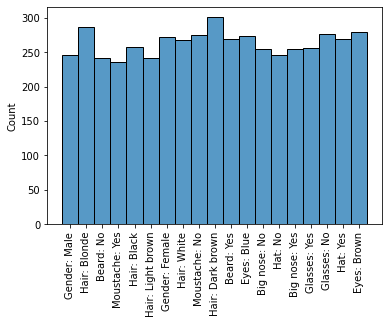

After 2_000 attempts:


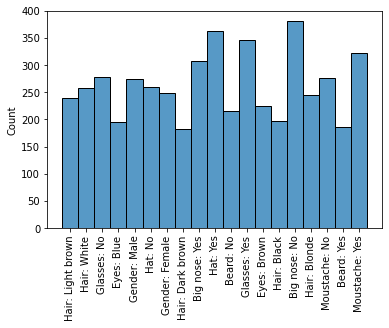

After 4_000 attempts:


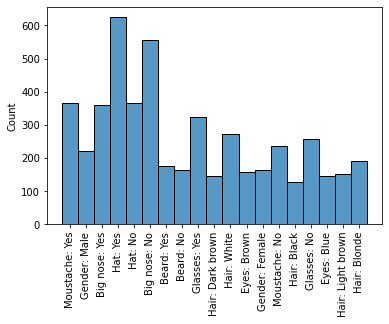

Asked about Hat == Yes, answer: No, table size: 24 -> 18
Asked about Gender == Female, answer: Yes, table size: 18 -> 3
Asked about Hair == White, answer: No, table size: 3 -> 2

After 6_000 attempts:


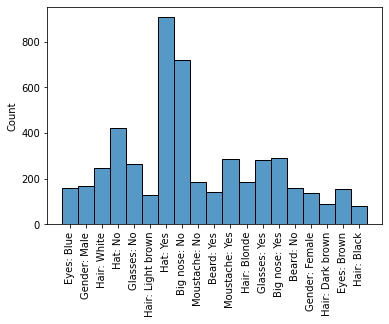

After 8_000 attempts:


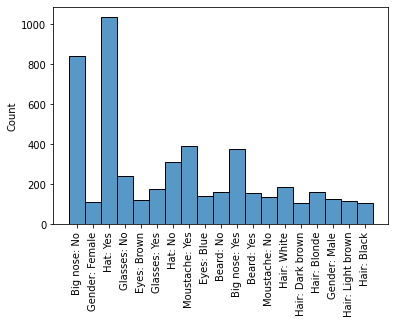

Asked about Gender == Male, answer: Yes, table size: 24 -> 19
Asked about Hat == Yes, answer: No, table size: 19 -> 15
Asked about Moustache == Yes, answer: No, table size: 15 -> 10
Asked about Beard == No, answer: Yes, table size: 10 -> 8
Asked about Hair == White, answer: Yes, table size: 8 -> 3
Asked about Big nose == No, answer: Yes, table size: 3 -> 2

Asked about Hat == Yes, answer: Yes, table size: 24 -> 6
Asked about Beard == Yes, answer: No, table size: 6 -> 5
Asked about Hair == Blonde, answer: No, table size: 5 -> 4
Asked about Hat == No, answer: No, but no filtering applied as it would eliminate no options.
Asked about Glasses == No, answer: Yes, table size: 4 -> 3
Asked about Gender == Female, answer: No, table size: 3 -> 2

After 10_000 attempts:


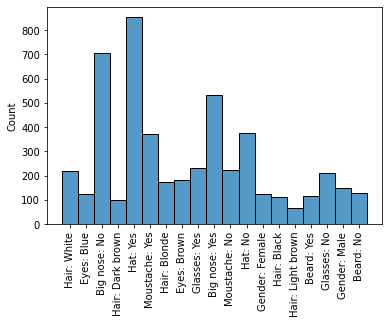

In [480]:
inizialize_questions()
questions_to_update = questions.copy()
baseline = 0.0
baseline_beta = 0.01

ATTEMPTS = 10_000
print(f"{ATTEMPTS=:_}")

for i in range(ATTEMPTS+1):
    print_logs = (random.randint(0, ATTEMPTS) <= 2)
    train(print_logs=print_logs, on_first_n_questions_only=10)
    if print_logs:
        print()
    if i % (ATTEMPTS // 5) == 0:
        print(f"After {i:_} attempts:")
        plot_distribution_of_questions(questions_to_update, trials=5_000)
        plt.show()

questions = questions_to_update.copy()

## AI Agent to play against

![](./guess_who_first_game_table.jpg)

In [483]:
# Choose your player
INDEX = 17 # <- modify this index if you want to play a different character
assert 0 <= INDEX < len(table), "INDEX out of range!"
your_person_row = table.iloc[INDEX]
display(your_person_row)

Name         Peter
Gender        Male
Eyes          Blue
Hair         White
Beard           No
Moustache       No
Big nose       Yes
Glasses         No
Hat             No
Name: 17, dtype: object

In [508]:
def ai_round():
    global your_person_row, ai_table, ai_available_questions
    if not ai_available_questions:
        return False
    if len(ai_table) > 2:
        rq_idx, rq = random_question(ai_available_questions)
        ai_available_questions.pop(rq_idx)
        feature = rq['feature']
        key = rq['key']
        answer = 'Yes' if your_person_row[feature] == key else 'No'
        filtered_table = (
            ai_table[ai_table[feature] == key]
            if answer == 'Yes'
            else ai_table[ai_table[feature] != key]
        )
        if len(filtered_table) == len(ai_table):
            return ai_round()
        print(f"AI Asked about {feature} == {key}, answer: {answer}, table size: {len(ai_table)} -> {len(filtered_table)}")
        ai_table = filtered_table
        return False
    if len(ai_table) == 2:
        guess = ai_table.iloc[random.randint(0,1)]
        if guess['Name'] == your_person_row['Name']:
            print(f"AI guesses: {guess['Name']} - Correct!")
            return True
        else:
            print(f"AI guesses: {guess['Name']} - Wrong!")
            ai_table = ai_table[ai_table['Name'] != guess['Name']]
            return False
    if len(ai_table) == 1:
        guess = ai_table.iloc[0]
        if guess['Name'] == your_person_row['Name']:
            print(f"AI guesses: {guess['Name']} - Correct!")
            return True
        else:
            print(f"AI guesses: {guess['Name']} - Wrong!")
            ai_table = ai_table[ai_table['Name'] != guess['Name']]
    return False

In [502]:
def your_round():    
    global ai_character, your_table, your_available_questions
    question = input('Feature to ask about (format: Feature=Key) or the name of a character: ')
    if '=' not in question:
        guess_name = question.strip()
        if guess_name == ai_character['Name']:
            print(f"You guessed: {guess_name} - Correct!")
            return True
        else:
            print(f"You guessed: {guess_name} - Wrong!")
            your_table = your_table[your_table['Name'] != guess_name]
        return False
    feature, key = question.split('=')
    key = key.strip()
    answer = 'Yes' if ai_character[feature] == key else 'No'
    filtered_table = (
        your_table[your_table[feature] == key]
        if answer == 'Yes'
        else your_table[your_table[feature] != key]
    )
    print(f"You asked about {feature} == {key}, answer: {answer}, table size: {len(your_table)} -> {len(filtered_table)}")
    your_table = filtered_table
    return False

In [507]:
print('\n'.join([q['feature'] + '=' + q['key'] for q in questions]))

Gender=Male
Gender=Female
Eyes=Brown
Eyes=Blue
Hair=Black
Hair=Light brown
Hair=Blonde
Hair=Dark brown
Hair=White
Beard=No
Beard=Yes
Moustache=Yes
Moustache=No
Big nose=No
Big nose=Yes
Glasses=No
Glasses=Yes
Hat=No
Hat=Yes


In [505]:
win = False
ai_table = table.copy()
your_table = table.copy()
ai_available_questions = questions.copy()
your_available_questions = questions.copy()
ai_character = random_person_row().iloc[0] # secret
rounds = [ai_round, your_round]
idx = 1
while not win:
    idx ^= 1
    win = rounds[idx]()

AI Asked about Eyes == Brown, answer: No, table size: 24 -> 5
You asked about Gender == Female, answer: Yes, table size: 24 -> 5
AI Asked about Big nose == No, answer: No, table size: 5 -> 2
You asked about Hat == Yes, answer: No, table size: 5 -> 3
AI guesses: Peter - Correct!
